# README для проекта «Модель кредитного риск-менеджмента»

## Описание проекта

В рамках итогового проекта курса Machine Learning Junior была разработана модель машинного обучения для прогнозирования дефолта клиентов банка по кредитным продуктам.
Целевая переменная - бинарный флаг flag (1 - дефолт, 0 - отсутствие дефолта).
Модель позволяет банку оценивать кредитный риск и принимать обоснованные решения о выдаче займов.

Достигнутое качество: ROC-AUC = 0.7507 на тестовой выборке (требуемый минимум - 0.75).

## Данные

Исходные данные предоставлены в виде 12 партиций формата .pq (Parquet) в папке train_data/.
Общий объём данных 4.5 ГБ, после распаковки увеличивается.
Также имеется файл целевой переменной train_target.csv.

Каждая запись соответствует одному кредитному продукту конкретного заёмщика и содержит:

идентификатор заявки (id),

порядковый номер продукта в кредитной истории (rn),

бинаризованные и закодированные признаки (pre_, enc_, is_zero_*, флаги закрытия),

историю ежемесячных платежей за последние 25 месяцев (enc_paym_0 ... enc_paym_24),

сведения о кредитных лимитах, просрочках, статусах и т.д.

## Структура репозитория

Проект состоит из следующих файлов:

- `1. Разведочный анализ.ipynb` – исследование данных, визуализация, анализ пропусков, корреляций, распределений.
- `2. Обучение модели.ipynb` – эксперименты с различными моделями, подбор гиперпараметров, сравнение качества.
- `3. Пайплайн.ipynb` – финальный пайплайн подготовки данных и обучения модели, сохранение модели и генерация предсказаний.
- `credit_risk_pipeline.pkl` – обученный пайплайн в формате pickle (готов к использованию в продакшене).
- `test_predictions.csv` – предсказания вероятностей дефолта для тестовой выборки (30% данных).
- `train_data/` – папка с исходными партициями (12 файлов .pq).
- `train_target.csv` – целевая переменная для всех клиентов.

Кроме того, в процессе работы создаются промежуточные файлы: `df_agg_final.csv`, `full_final.csv`, `X_train.csv`, `y_train.csv` и др. – они не обязательны для воспроизведения, так как пайплайн сам выполняет все преобразования. Эти файлы были необходимы мне в связи с ограничениями моего компьютера.

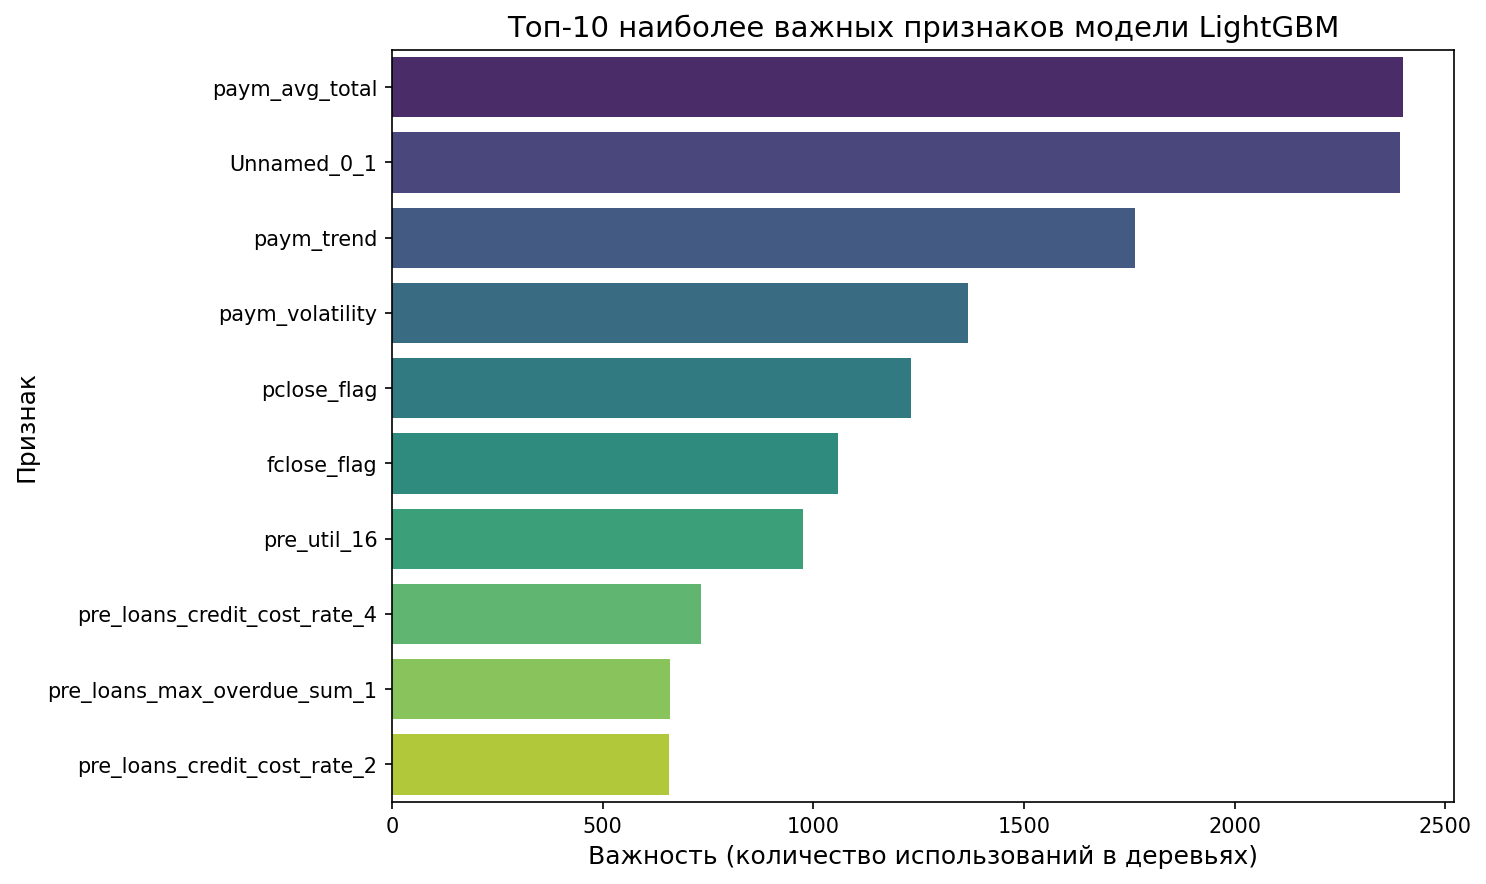

In [1]:
from IPython.display import Image

Image(filename='feature_importance_top10.png')

График подтверждает, что модель опирается на экономически обоснованные факторы: платёжная дисциплина, динамика поведения, текущая закредитованность и история просрочек. Это делает модель не только точной (ROC‑AUC = 0.7507), но и интерпретируемой для бизнес-пользователей.